<a href="https://colab.research.google.com/github/ishejaladouce/PCA-Formative_1_Pair_11/blob/main/PCA_Formative_1_Pair_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





**step 0 : Data Acausition**
This data is attined from the worldbank group using the api.

In [ ]:
pip install wbgapi

In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
indicators_for_use= {
    'AG.YLD.CREL.KG': 'cereal_yield',
    'AG.CON.FERT.ZS': 'fertilizer_user',
    'AG.LND.AGRI.ZS': 'agri_land_pct',
    'NV.AGR.TOTL.ZS': 'agri_value_added_pct',
    'SP.RUR.TOTL.ZS': 'rural_pop_pct',
    'SN.ITK.DEFC.ZS': 'undernourishment_pct',
    'NY.GDP.PCAP.CD' : 'gdp_per_capacita',
    'AG.PRD.FOOD.XD': 'food_production',
    'EG.ELC.ACCS.ZS': 'electricity',

}

wb.series.info(list(indicators_for_use))

id,value
EG.ELC.ACCS.ZS,Access to electricity (% of population)
AG.LND.AGRI.ZS,Agricultural land (% of land area)
NV.AGR.TOTL.ZS,"Agriculture, forestry, and fishing, value added (% of GDP)"
AG.YLD.CREL.KG,Cereal yield (kg per hectare)
AG.CON.FERT.ZS,Fertilizer consumption (kilograms per hectare of arable land)
AG.PRD.FOOD.XD,Food production index (2014-2016 = 100)
NY.GDP.PCAP.CD,GDP per capita (current US$)
SN.ITK.DEFC.ZS,Prevalence of undernourishment (% of population)
SP.RUR.TOTL.ZS,Rural population (% of total population)
,9 elements


In [ ]:
african= list(wb.region.members('SSF')) + ['DZA', 'EGY', 'LBY', 'MAR', 'TUN','DJI']
print(len(african), "countries")

54 countries


In [ ]:
df_agri=wb.data.DataFrame(list(indicators_for_use), economy=african,
                          time=range(2000,2023),
                          columns = 'series', numericTimeKeys=True)
df_agri =df_agri.rename(columns=indicators_for_use).reset_index()
df_agri= df_agri.rename(columns={'economy': 'country_code','time': 'year'})

meta= wb.economy.DataFrame(african)[['incomeLevel']]
df_agri=df_agri.merge(meta, left_on='country_code', right_index=True)
df_agri = df_agri.rename(columns={'incomeLevel': 'income_group'})
print(df_agri.shape)
df_agri.head()

(1242, 12)


,country_code,year,fertilizer_user,agri_land_pct,food_production,cereal_yield,electricity,agri_value_added_pct,gdp_per_capacita,undernourishment_pct,rural_pop_pct,income_group
0,AGO,2000,0.466667,35.712681,32.16,564.4,24.2,NaN,563.733796,NaN,49.492935,LMC
1,AGO,2001,NaN,35.626053,36.90,585.4,20.0,NaN,533.586202,67.8,48.277521,LMC
2,AGO,2002,1.659032,35.644501,41.72,627.2,26.3,9.386791,999.065856,63.6,47.107377,LMC
3,AGO,2003,1.788788,35.693431,45.12,646.1,27.4,10.000077,1133.663320,57.5,45.995645,LMC
4,AGO,2004,4.501515,35.541830,48.23,491.7,28.4,10.363591,1451.471179,50.6,44.955472,LMC


In [ ]:
numeric_cols = list(indicators_for_use.values())
X_raw = df_agri[numeric_cols].to_numpy(dtype=float)
country_codes = df_agri['country_code'].to_numpy()
income = df_agri['income_group'].to_numpy()      # non-numeric column: used for plot colours, not in the PCA
print("Numeric data shape:", X_raw.shape)
print("Income groups:", np.unique(income))

Numeric data shape: (1242, 9)
Income groups: ['HIC' 'LIC' 'LMC' 'UMC']


In [ ]:
missing_share = np.isnan(X_raw).mean(axis=0)
print("Total missing values:", np.isnan(X_raw).sum())
for name, share in zip(numeric_cols, missing_share):
    print(f"{name:26s} {share:.0%}")

Total missing values: 460
cereal_yield               5%
fertilizer_user            4%
agri_land_pct              2%
agri_value_added_pct       7%
rural_pop_pct              0%
undernourishment_pct       14%
gdp_per_capacita           2%
food_production            2%
electricity                1%


In [ ]:
keep = missing_share <= 0.4
print("Dropping:", [c for c, k in zip(numeric_cols, keep) if not k])
numeric_cols = [c for c, k in zip(numeric_cols, keep) if k]
X_raw = X_raw[:, keep]

col_medians = np.nanmedian(X_raw, axis=0)
X = np.where(np.isnan(X_raw), col_medians, X_raw)
print(len(numeric_cols), "features kept | missing values left:", np.isnan(X).sum())

Dropping: []
9 features kept | missing values left: 0


In [ ]:
gdp_i = numeric_cols.index('gdp_per_capacita')
print("Mean GDP per capita:  ", np.nanmean(X_raw[:, gdp_i]).round(0))
print("Median GDP per capita:", np.nanmedian(X_raw[:, gdp_i]).round(0))

Mean GDP per capita:   2262.0
Median GDP per capita: 1048.0


GDP per capita has a few extremely high values, so we used the median because, unlike the mean, it isn't pulled upward by those extremes. In the cell above, the mean is almost double the median.

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

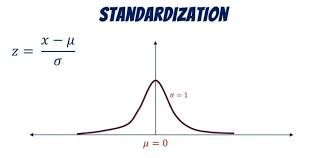


Loading data

In [ ]:
mean = np.mean(X, axis =0)
std = np.std(X, axis=0, ddof=1)
standardized_data = (X - mean) / std

print("Means:", standardized_data.mean(axis=0).round(3))
print("Std devs:", standardized_data.std(axis=0, ddof=1).round(3))
standardized_data[:5]

Means: [-0.  0. -0.  0. -0. -0. -0.  0. -0.]
Std devs: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[-0.72248323, -0.37271135, -0.42346529, -0.0681111 , -0.45495546,
        -0.17992595, -0.57275054, -2.7738364 , -0.70240439],
       [-0.70607273, -0.26911166, -0.42734199, -0.0681111 , -0.52245012,
         4.11980815, -0.58307302, -2.55658085, -0.84582157],
       [-0.67340801, -0.35993929, -0.4265164 , -0.8037286 , -0.58743087,
         3.76536491, -0.42369355, -2.33565853, -0.63069579],
       [-0.65863856, -0.35854941, -0.42432678, -0.75295205, -0.6491678 ,
         3.25057829, -0.37760759, -2.17982121, -0.59313415],
       [-0.77929482, -0.32949196, -0.431111  , -0.72285514, -0.70693098,
         2.66827868, -0.2687907 , -2.03727589, -0.5589872 ]])

### Step 3: Calculate the Covariance Matrix

We compute the covariance matrix to see how features vary together. It shows which features overlap, so PCA can merge them into fewer, more useful components. Its eigenvectors and eigenvalues then give us the principal components and how much variance each one explains, so we know which direction to keep.

In [ ]:
n = standardized_data.shape[0]

cov_matrix = (standardized_data.T @ standardized_data) / (n -1)
cov_matrix.round(2)

array([[ 1.  ,  0.66, -0.03, -0.14, -0.02, -0.25,  0.16,  0.1 ,  0.39],
       [ 0.66,  1.  , -0.26, -0.26, -0.05, -0.27,  0.4 ,  0.1 ,  0.46],
       [-0.03, -0.26,  1.  ,  0.09,  0.3 ,  0.08, -0.34,  0.14, -0.16],
       [-0.14, -0.26,  0.09,  1.  ,  0.52,  0.24, -0.6 , -0.16, -0.57],
       [-0.02, -0.05,  0.3 ,  0.52,  1.  ,  0.24, -0.49, -0.14, -0.67],
       [-0.25, -0.27,  0.08,  0.24,  0.24,  1.  , -0.35, -0.13, -0.52],
       [ 0.16,  0.4 , -0.34, -0.6 , -0.49, -0.35,  1.  ,  0.19,  0.63],
       [ 0.1 ,  0.1 ,  0.14, -0.16, -0.14, -0.13,  0.19,  1.  ,  0.24],
       [ 0.39,  0.46, -0.16, -0.57, -0.67, -0.52,  0.63,  0.24,  1.  ]])

In [ ]:
print("Diagonal:", np.diag(cov_matrix).round(3))
print("Symetric:", np.allclose(cov_matrix, cov_matrix.T))
print("Matches np.cov:", np.allclose(cov_matrix, np.cov(standardized_data, rowvar=False)))

Diagonal: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Symetric: True
Matches np.cov: True


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues:" , eigenvalues.round(4))
print("sum of eigenvalues:", eigenvalues.sum().round(4), "| number of features:", len(numeric_cols)) # Perform eigendecomposition
eigenvalues, eigenvectors

Eigenvalues: [0.1518 0.2544 0.3293 0.561  0.7369 0.8061 1.194  1.4577 3.5088]
sum of eigenvalues: 9.0 | number of features: 9


(array([0.151826  , 0.25441167, 0.32932376, 0.56097255, 0.73688207,
        0.80608901, 1.19400303, 1.45766841, 3.5088235 ]),
 array([[-0.03974685,  0.58419549,  0.16949737,  0.35526385, -0.19834474,
          0.036749  , -0.01412247,  0.63084092, -0.2516808 ],
        [-0.28753405, -0.63928194, -0.11919023, -0.15475431, -0.0497298 ,
          0.20460932, -0.1941684 ,  0.53094211, -0.32641789],
        [-0.21333819, -0.07646324, -0.32768983, -0.05445089, -0.46312845,
         -0.27354783,  0.70575041,  0.13446783,  0.18114373],
        [-0.06826051,  0.04673355, -0.62634525,  0.337998  ,  0.51395373,
         -0.07589561, -0.11625217,  0.24478371,  0.37850133],
        [ 0.53057344,  0.08535238,  0.05164299, -0.61390611,  0.05914407,
          0.01778687,  0.01500307,  0.44684357,  0.35770158],
        [ 0.16812942, -0.01086067, -0.23022441,  0.1962215 , -0.48432819,
          0.72361054, -0.13747484, -0.10441534,  0.30351355],
        [-0.15916761,  0.44017938, -0.54186064, -0.4951492

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
sorted_indices = np.argsort(eigenvalues)[::1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[-0.03974685,  0.58419549,  0.16949737,  0.35526385, -0.19834474,
         0.036749  , -0.01412247,  0.63084092, -0.2516808 ],
       [-0.28753405, -0.63928194, -0.11919023, -0.15475431, -0.0497298 ,
         0.20460932, -0.1941684 ,  0.53094211, -0.32641789],
       [-0.21333819, -0.07646324, -0.32768983, -0.05445089, -0.46312845,
        -0.27354783,  0.70575041,  0.13446783,  0.18114373],
       [-0.06826051,  0.04673355, -0.62634525,  0.337998  ,  0.51395373,
        -0.07589561, -0.11625217,  0.24478371,  0.37850133],
       [ 0.53057344,  0.08535238,  0.05164299, -0.61390611,  0.05914407,
         0.01778687,  0.01500307,  0.44684357,  0.35770158],
       [ 0.16812942, -0.01086067, -0.23022441,  0.1962215 , -0.48432819,
         0.72361054, -0.13747484, -0.10441534,  0.30351355],
       [-0.15916761,  0.44017938, -0.54186064, -0.49514925,  0.00304782,
         0.14500332, -0.08915759, -0.17340828, -0.42786364],
       [ 0.00230407,  0.00588654,  0.14342461,  0.02066485,  0

Explained variance per component (%): [ 1.69  2.83  3.66  6.23  8.19  8.96 13.27 16.2  38.99]
cumulative (%): [  1.69   4.51   8.17  14.41  22.59  31.55  44.82  61.01 100.  ]


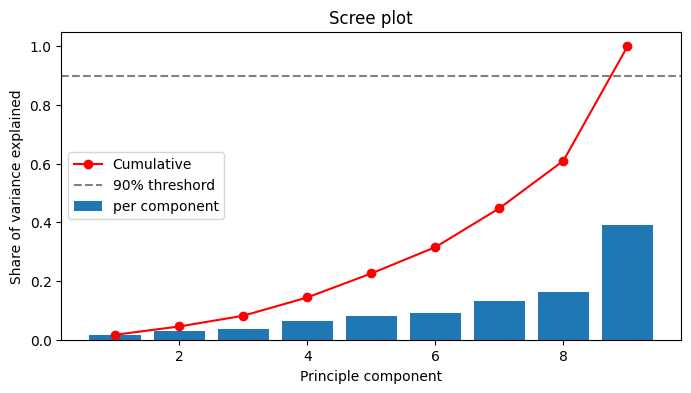

In [ ]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)
print("Explained variance per component (%):", (explained_variance_ratio * 100).round(2))
print("cumulative (%):", (cumulative_variance * 100).round(2))

components = np.arange(1, len(explained_variance_ratio) + 1)
plt.figure(figsize=(8, 4))
plt.bar(components, explained_variance_ratio, label='per component')
plt.plot(components, cumulative_variance, 'o-', color='red', label='Cumulative')
plt.axhline(0.90, linestyle='--', color='gray', label='90% threshord')
plt.xlabel('Principle component'); plt.ylabel('Share of variance explained')
plt.title('Scree plot'); plt.legend(); plt.show()



### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = None  # Decide on the number of principal components to keep
reduced_data = None  # Project data onto the principal components
reduced_data[:5]

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
X_feat, y_feat = 'gdp_per_capacita', 'rural_pop_pct'
xi, yi = numeric_cols.index(X_feat), numeric_cols.index(y_feat)
pc_view = standardized_data @ sorted_eigenvectors[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for g in np.unique(income):
  m = income == g

  axes[0].scatter(standardized_data[m, xi],
                  standardized_data[m, yi], s=12, alpha=0.6, label=g)
  axes[1].scatter(pc_view[m, 0], pc_view[m, 1], s=12, alpha=0.6, label=g)

axes[0].set(title='Before PCA: two origial features (standardized)',
            xlabel=X_feat, ylabel=y_feat)
axes[1].set(title='After PCA: PC1 vs PC2',
            xlabel=f'PC1 ({explained_variance_ratio[0]:.1%})',
            ylabel=f'PC2 ({explained_variance_ratio[1]:.1%} of variance)'
            )
for ax in axes:
  ax.legend(title='Income group')
  ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
for pc in range(num_components):
  top = np.argsort(np.abs(sorted_eigenvectors[:, pc]))[::-1][:4]
  print(f"PC{pc+1} ({explained_variance_ratio[pc]:.1%}):",
        ", ".join(f"{numeric_cols[i]} ({sorted_eigenvectors[i, pc]:+.2f})" for i in top))

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
